# 1. Pipeline A – Physically consistent model with known inertia J
## 1.1. Model

We keep the same structure:
$$
𝑘_𝑚 𝑖_q = J\dot{\omega} + 𝐵 \omega + \tau_c sign(\omega) + \tau_s 𝑒^{\frac{\|\omega|}{\omega_s}}
$$
Now J is known, so parameters to estimate:

- $𝐵$
- $𝜏_c$
- $𝜏_s$ 
- $𝜔_s$
- $𝑘_𝑚$ (optional)  (optional – can be fixed if datasheet value is trusted)

In [48]:
import pandas as pd
import numpy as np
from scipy.optimize import least_squares
import glob

# ---------- CONFIG ----------
J_KNOWN = 0.002  # <-- put your actual inertia here (kg·m²)
ESTIMATE_KM = True
KM_FIXED = 1.3   # use only if ESTIMATE_KM = False
# ----------------------------

def model_iq(params, omega, domega_dt, J, estimate_km=True, km_fixed=1.0):
    """
    params = [B, tau_c, tau_s, omega_s]
    """
    if estimate_km:
        B, tau_c, tau_s, omega_s, km = params
    else:
        B, tau_c, tau_s, omega_s = params
        km = km_fixed

    # torque balance -> iq
    tau = J * domega_dt \
          + B * omega \
          + tau_c * np.sign(omega) \
          + tau_s * np.exp(-np.abs(omega) / omega_s)

    iq_model = tau / km
    return iq_model

def residuals(params, omega, domega_dt, iq, J, estimate_km=True, km_fixed=1.0):
    iq_hat = model_iq(params, omega, domega_dt, J, estimate_km, km_fixed)
    return iq_hat - iq

def identify_physical_params_known_J(df,
                                     J_known,
                                     estimate_km=True,
                                     km_fixed=1.0):
    t = df["time"].values
    omega = df["omega"].values
    iq = df["iq"].values

    domega_dt = np.gradient(omega, t)

    # ---- initial guesses ----
    if estimate_km:
        # [B, tau_c, tau_s, omega_s, km]
        p0 = np.array([0.01, 0.3, 0.3, 200.0, 1.0])
        lower = [0.0,  0.0,  0.0,  1.0,  0.01]
        upper = [np.inf, np.inf, np.inf, 1e5, np.inf]
    else:
        # [B, tau_c, tau_s, omega_s]
        p0 = np.array([0.01, 0.3, 0.3, 200.0])
        lower = [0.0,  0.0,  0.0,  1.0]
        upper = [np.inf, np.inf, np.inf, 1e5]

    result = least_squares(
        residuals,
        p0,
        bounds=(lower, upper),
        args=(omega, domega_dt, iq, J_known, estimate_km, km_fixed),
    )

    params = result.x
    cost = result.cost

    if estimate_km:
        B, tau_c, tau_s, omega_s, km = params
    else:
        B, tau_c, tau_s, omega_s = params
        km = km_fixed

    return {
        "B": B,
        "tau_c": tau_c,
        "tau_s": tau_s,
        "omega_s": omega_s,
        "km": km,
        "loss": cost
    }

# ---------- loop over csv files ----------
physical_results = []

for file in glob.glob("*.csv"):
    df = pd.read_csv(file)

    res = identify_physical_params_known_J(
        df,
        J_known=J_KNOWN,
        estimate_km=ESTIMATE_KM,
        km_fixed=KM_FIXED
    )

    res["file"] = file
    physical_results.append(res)

physical_df = pd.DataFrame(physical_results)
print(physical_df)


EmptyDataError: No columns to parse from file

# 2. Pipeline B – Monitoring metric with known JJJ
Here J doesn’t enter the “physics” of the metric (we still use iq≈(B/km)ωi_q \approx (B/k_m)\omegaiq​≈(B/km​)ω at constant speed), but we can use JJJ to make the steady-state detection non-arbitrary:


Previously: “steady if ∣dω/dt∣<threshold|d\omega/dt| < \text{threshold}∣dω/dt∣<threshold”.


Now: “steady if inertial torque ∣Jω˙∣|J \dot{\omega}|∣Jω˙∣ is small relative to total torque kmiqk_m i_qkm​iq​”.


Since kmk_mkm​ may be unknown, we can do it dimensionless:
$$
r = \frac{|J\dot{\omega}|}{|J\dot{\omega}| + |i_q|}r=∣Jω˙∣+∣iq​∣∣Jω˙∣
​$$
If r is small, inertial contribution is negligible relative to current-related torque → segment is steady enough.

## 2.1. Implementation

In [49]:

import pandas as pd
import numpy as np
import glob

J_KNOWN = 0.002  # same J as above

def extract_steady_state_using_J(df,
                                 J,
                                 r_max=0.1,
                                 min_samples=100):
    """
    r = |J dω/dt| / (|J dω/dt| + |iq|)
    require r < r_max to call it 'steady'.
    """
    t = df["time"].values
    omega = df["omega"].values
    iq = df["iq"].values

    domega_dt = np.gradient(omega, t)

    num = np.abs(J * domega_dt)
    den = np.abs(J * domega_dt) + np.abs(iq) + 1e-9
    r = num / den

    mask = r < r_max
    ss_df = df[mask]

    if len(ss_df) < min_samples:
        return None

    return {
        "omega_mean": ss_df["omega"].mean(),
        "iq_mean": ss_df["iq"].mean(),
        "omega_std": ss_df["omega"].std(),
        "iq_std": ss_df["iq"].std(),
        "n_samples": len(ss_df)
    }

steady_results = []

for file in glob.glob("*.csv"):
    df = pd.read_csv(file)
    ss = extract_steady_state_using_J(df, J=J_KNOWN)

    if ss is None:
        continue

    # proxy B/km = i_q / ω at steady state
    B_over_km = ss["iq_mean"] / ss["omega_mean"]

    steady_results.append({
        "file": file,
        "omega_mean": ss["omega_mean"],
        "iq_mean": ss["iq_mean"],
        "omega_std": ss["omega_std"],
        "iq_std": ss["iq_std"],
        "n_samples": ss["n_samples"],
        "B_over_km": B_over_km
    })

steady_df = pd.DataFrame(steady_results)
print(steady_df)

EmptyDataError: No columns to parse from file

## 2.2. Optional global regression for B/kₘ


In [ ]:
from sklearn.linear_model import LinearRegression

X = steady_df[["omega_mean"]]
y = steady_df["iq_mean"]

reg = LinearRegression().fit(X, y)
B_over_km_global = reg.coef_[0]
iq_offset = reg.intercept_

print("Global B/km =", B_over_km_global)
print("Offset (should be near zero) =", iq_offset)


If the offset is not small, that’s a hint your friction is not purely viscous, i.e., Coulomb terms or temperature effects are leaking into the fit — which is exactly what you should expect in reality.

# 3. How to use both together (conceptually)


Pipeline A: use a subset of rich excitation data (ramps, starts, stops) to identify:


$B$, $\tau_c$,$\tau_s$,$\omega_s$,$k_m$​ with fixed J.




Pipeline B: deploy online in production:


at each constant-speed phase, compute a fresh estimate of $B/k_m$​,


compare to baseline to detect drift due to tool wear, bearing degradation, misalignment, etc.




If you tell me:


the numerical value of your J,


whether you know $k_m$​ and trust it,


I can compress this into a single class (e.g. SpindleIdentifier) that fits neatly into your existing MachineToolParser and returns a dictionary with all parameters and health metrics.

## Robust Pipeline for Detecting Constant-Velocity Sections and Regression

In [62]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# data folder
folder = Path("../../../../data/preprocessed/HSA")

results = []

def find_constant_velocity_segments(df, vel_col="velAx4", window=200, std_q=0.4, slope_q=0.4):
    """Return list of (start, end) index tuples representing constant-velocity segments."""
    v = df[vel_col].to_numpy()
    # velocity derivative
    dv = np.gradient(v)

    # rolling stats
    roll_std = pd.Series(v).rolling(window, center=True).std()
    roll_slope = pd.Series(dv).rolling(window, center=True).mean()
    ## test plots
    # plt.figure(figsize=(12,6))
    # plt.plot(df["time"], df["velAx4"], linewidth=1, marker='o', markersize=4, linestyle='None')
    #plt.show()
    ##
    # quantile thresholds (robust against noise)
    std_th = roll_std.quantile(std_q)
    slope_th = roll_slope.abs().quantile(slope_q)

    mask = (roll_std < std_th*1.3) & (roll_slope.abs() < slope_th*2)
    #print(f"Std threshold: {std_th}, Slope threshold: {slope_th}")
    #print(f'roll_std:\n{roll_std} \nroll_slope:\n{roll_slope}\n')
    #print(f'mask before filling NaN:\n{mask.isna().sum}\n')
    mask = mask.fillna(False)
    #print(mask)

    ## test plots
    # plt.plot(df["time"][mask], df["velAx4"][mask], linewidth=1, marker='o', markersize=4, linestyle='None')
    # plt.show()
    ##

    segments = []
    current_start = None

    for i, val in enumerate(mask):
        if val and current_start is None:
            current_start = i
        elif not val and current_start is not None:
            if i - current_start > window:     # enforce minimum length
                segments.append((current_start, i))
            current_start = None

    return segments




Processing Trace_1028_161651.csv...
  Found 60 constant-velocity segments.
Processing Trace_1028_162435.csv...
  Found 23 constant-velocity segments.
Processing Trace_1030_110641.csv...
  Found 3 constant-velocity segments.
Processing Trace_1030_122711.csv...
  Found 4 constant-velocity segments.
Processing Trace_1030_123420.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_123530.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_123701.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_123727.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_123752.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_123912.csv...
  Found 4 constant-velocity segments.
Processing Trace_1030_123937.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_124002.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_124027.csv...
  Found 3 constant-velocity segments.
Processing Trace_1030_124052.csv...


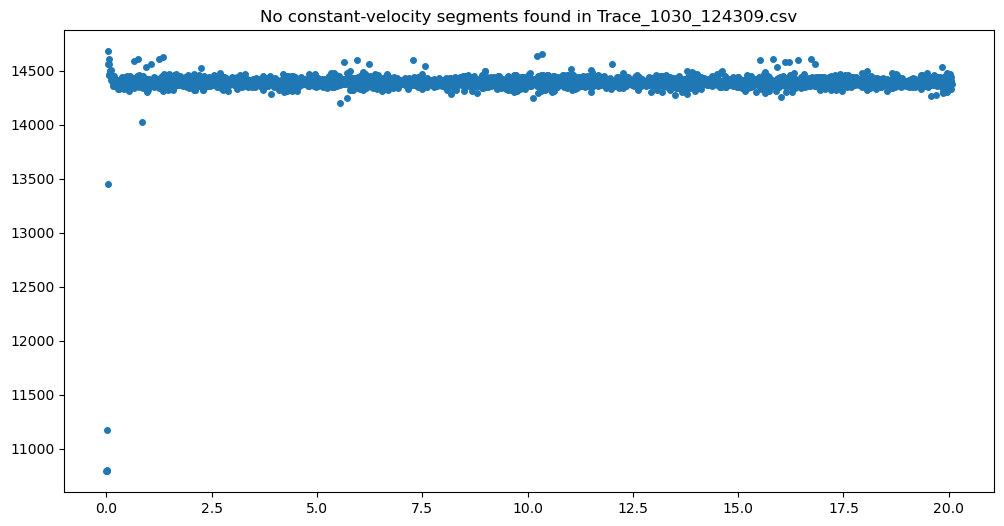

Processing Trace_1030_124334.csv...
  Found 2 constant-velocity segments.
Processing Trace_1030_124359.csv...
  Found 4 constant-velocity segments.
Processing Trace_1030_124424.csv...
  Found 0 constant-velocity segments.


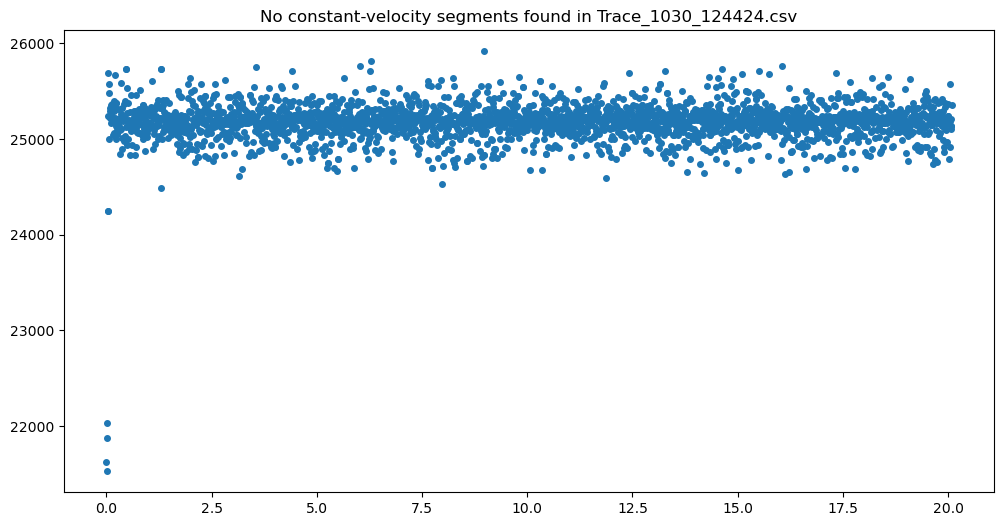

Processing Trace_1030_124450.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_124515.csv...
  Found 5 constant-velocity segments.
Processing Trace_1030_124540.csv...
  Found 2 constant-velocity segments.
Processing Trace_1030_124633.csv...
  Found 5 constant-velocity segments.
Processing Trace_1030_124658.csv...
  Found 3 constant-velocity segments.
Processing Trace_1030_124723.csv...
  Found 3 constant-velocity segments.
Processing Trace_1030_124748.csv...
  Found 4 constant-velocity segments.
Processing Trace_1030_124814.csv...
  Found 3 constant-velocity segments.
Processing Trace_1030_124839.csv...
  Found 3 constant-velocity segments.
Processing Trace_1030_124904.csv...
  Found 3 constant-velocity segments.
Processing Trace_1030_125002.csv...
  Found 2 constant-velocity segments.
Processing Trace_1030_125027.csv...
  Found 3 constant-velocity segments.
Processing Trace_1030_125052.csv...
  Found 5 constant-velocity segments.
Processing Trace_1030_125117.csv...
  

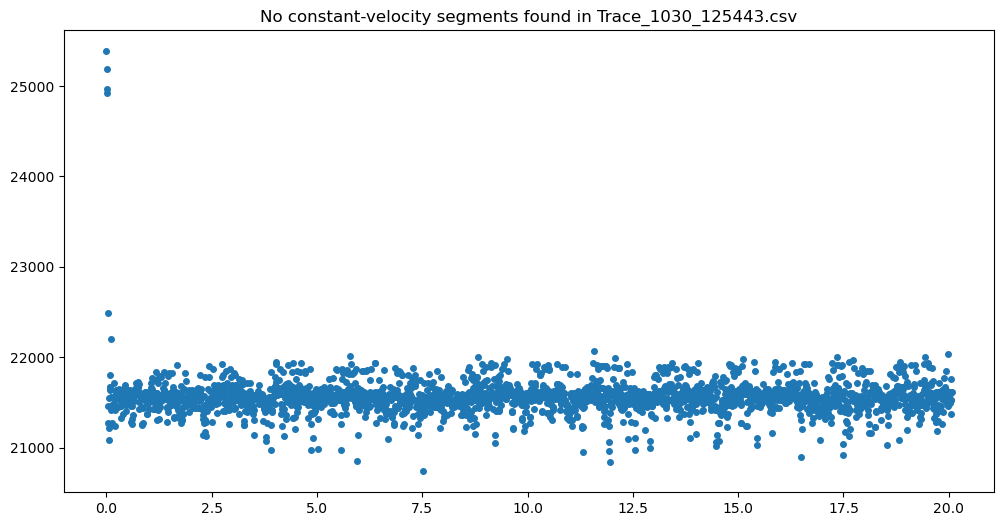

Processing Trace_1030_125508.csv...
  Found 2 constant-velocity segments.
Processing Trace_1030_125533.csv...
  Found 0 constant-velocity segments.


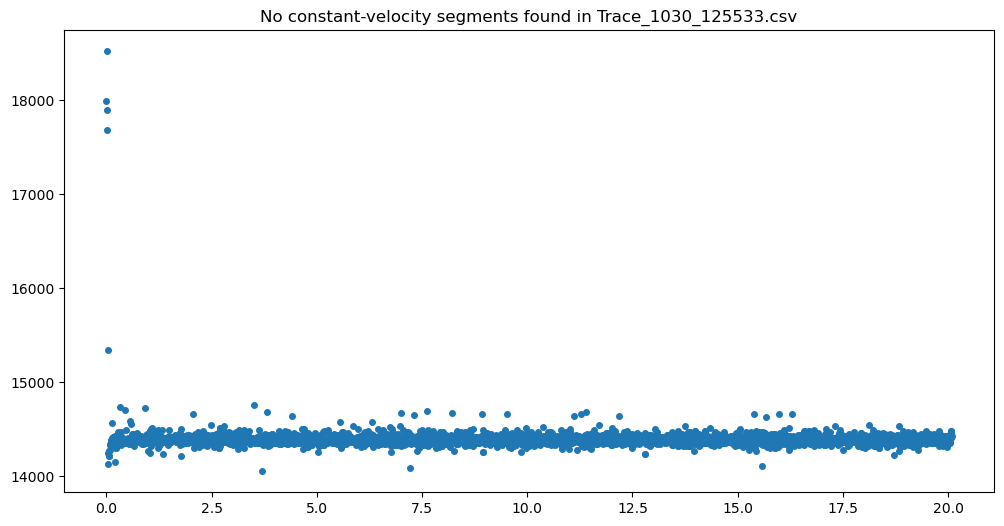

Processing Trace_1030_125558.csv...
  Found 4 constant-velocity segments.
Processing Trace_1030_125623.csv...
  Found 2 constant-velocity segments.
Processing Trace_1030_125649.csv...
  Found 5 constant-velocity segments.
Processing Trace_1030_125734.csv...
  Found 3 constant-velocity segments.
Processing Trace_1030_125800.csv...
  Found 2 constant-velocity segments.
Processing Trace_1030_125825.csv...
  Found 2 constant-velocity segments.
Processing Trace_1030_125850.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_125915.csv...
  Found 2 constant-velocity segments.
Processing Trace_1030_125940.csv...
  Found 4 constant-velocity segments.
Processing Trace_1030_130005.csv...
  Found 2 constant-velocity segments.
Processing Trace_1030_130030.csv...
  Found 1 constant-velocity segments.
Processing Trace_1030_130055.csv...
  Found 1 constant-velocity segments.


In [73]:
files = list(folder.glob("*.csv"))
file_idx = 0
if not files:
    print("No CSV files found in this folder:", folder)
for file in folder.glob("*.csv"):
    
    ## added to check
    #roll_std = pd.Series(df["velAx4"]).rolling(200, center=True).std()
    #roll_slope = pd.Series(np.gradient(df["velAx4"])).rolling(200, center=True).mean()

    #print("STD quantiles:", roll_std.quantile([0.01, 0.1, 0.5]).to_dict())
    #print("Slope quantiles:", roll_slope.abs().quantile([0.01, 0.1, 0.5]).to_dict())

    ## added to check END

    print(f"Processing {file.name}...")
    df = pd.read_csv(file)
    segments = find_constant_velocity_segments(df, vel_col="velAx4", window=200, std_q=.8, slope_q=.8)
    print(f"  Found {len(segments)} constant-velocity segments.")
    if len(segments) == 0:
        plt.figure(figsize=(12,6))
        plt.plot(df["time"], df["velAx4"], linewidth=1, marker='o', markersize=4, linestyle='None')
        plt.title(f"No constant-velocity segments found in {file.name}")
        plt.show()

    for j, (s, e) in enumerate(segments):
        seg = df.iloc[s:e]
        file_idx += 1
        results.append({
            "file": file.name,
            "segment_id": j,
            "mean_velocity": seg["velAx4"].mean(),
            "mean_current": seg["iqAx4"].mean()
        })
results_df = pd.DataFrame(results)
#print(results_df)

In [74]:
results_df
file_idx

218

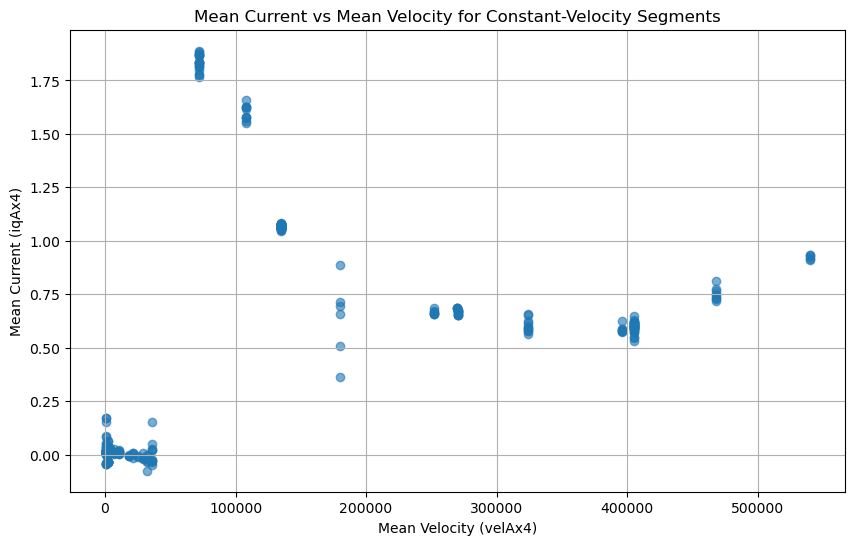

In [75]:
plt.figure(figsize=(10,6))
plt.scatter(results_df["mean_velocity"], results_df["mean_current"], alpha=0.6)
plt.xlabel("Mean Velocity (velAx4)")
plt.ylabel("Mean Current (iqAx4)")
plt.title("Mean Current vs Mean Velocity for Constant-Velocity Segments")   
plt.grid(True)
plt.show()

In [77]:
print("Folder path:", folder)
print("Absolute path:", folder.resolve())
print("Exists? ", folder.exists())
print("Is directory? ", folder.is_dir())
print("Files inside:", list(folder.iterdir()))


Folder path: ..\..\..\..\data\preprocessed\HSA
Absolute path: C:\Users\thmru\github\2025_LM_FinalProject\data\preprocessed\HSA
Exists?  True
Is directory?  True
Files inside: [WindowsPath('../../../../data/preprocessed/HSA/Trace_1028_161651.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1028_162435.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1030_110641.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1030_122711.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1030_123420.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1030_123530.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1030_123701.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1030_123727.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1030_123752.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1030_123912.csv'), WindowsPath('../../../../data/preprocessed/HSA/Trace_1030_123937.csv'), WindowsPath('../../../../data/pr

In [82]:
import numpy as np
from scipy.optimize import curve_fit

# Your nonlinear model
def friction_model(omega, B, tau_s, omega_0):
    return B * omega + tau_s * np.exp(-omega / omega_0)


In [ ]:
mask = np.abs(results_df["mean_current"]) < 0.25
omega = results_df["mean_velocity"].values
Iq    = results_df["mean_current"].values

# Initial parameter guesses (very important!)
B0      = np.max(Iq) / np.max(omega) * 0.1
tau_s0  = np.min(Iq)
omega00 = np.mean(omega) / 5

p0 = [B0, tau_s0, omega00]

params, covariance = curve_fit(
    friction_model,
    omega,
    Iq,
    p0=p0,
    maxfev=10000
)

B_est, tau_s_est, omega_0_est = params
print("Estimated B       =", B_est)
print("Estimated tau_s   =", tau_s_est)
print("Estimated omega_0 =", omega_0_est)


Estimated B       = 5.2402454998760415e-06
Estimated tau_s   = -0.05212540395663412
Estimated omega_0 = -133594.04347679473


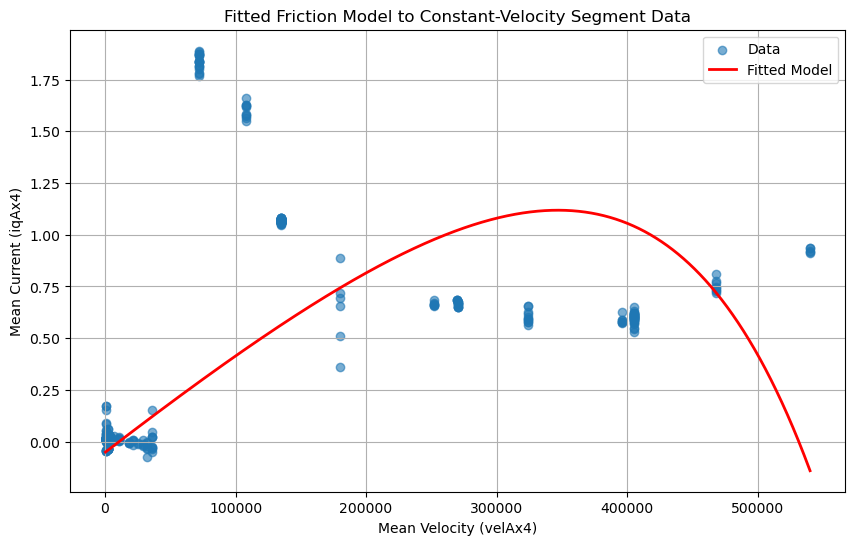

In [87]:
omega_sim = np.linspace(np.min(omega), np.max(omega), 100000)
Iq_sim = friction_model(omega_sim, B_est, tau_s_est, omega_0_est)
plt.figure(figsize=(10,6))
plt.scatter(omega, Iq, alpha=0.6, label="Data")
plt.plot(omega_sim, Iq_sim, color='red', label="Fitted Model", linewidth=2)
plt.xlabel("Mean Velocity (velAx4)")            
plt.ylabel("Mean Current (iqAx4)")
plt.title("Fitted Friction Model to Constant-Velocity Segment Data")
plt.legend()
plt.grid(True)
plt.show()